# Практика 18. Множинна лінійна регресія

**Варіант 7 — Івано-Франківськ**

Мета роботи: побудувати моделі множинної лінійної регресії, проаналізувати коефіцієнти предикторів, перевірити мультиколінеарність за допомогою VIF, порівняти R² та adjusted R² і виконати діагностику залишків.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import shapiro, probplot
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [10]:
np.random.seed(42)

city = "Івано-Франківськ"
mean_temp = 7.8
amplitude = 12
hum_base = 77

rows = []

for month in range(1, 13):
    temp = (
        mean_temp
        + amplitude * np.cos((month - 7) / 12 * 2 * np.pi)
        + np.random.normal(0, 1.0)
    )

    humidity = hum_base + np.random.normal(0, 5.0)

    if temp < 8:
        opal_days = 30
    elif temp < 12:
        opal_days = 15
    else:
        opal_days = 0

    cost = (
        200
        - 9.0 * temp
        + 0.6 * humidity
        + 2.5 * opal_days
        + np.random.normal(0, 15)
    )

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": round(temp, 1),
        "вологість": round(humidity, 1),
        "опалювальні_дні": opal_days,
        "витрати_на_опалення": round(cost, 1),
    })

heating = pd.DataFrame(rows)

print(heating)

               місто  місяць  температура  вологість  опалювальні_дні  \
0   Івано-Франківськ       1         -3.7       76.3               30   
1   Івано-Франківськ       2         -1.1       75.8               30   
2   Івано-Франківськ       3          3.4       80.8               30   
3   Івано-Франківськ       4          8.3       74.7               15   
4   Івано-Франківськ       5         14.0       67.4                0   
5   Івано-Франківськ       6         17.6       71.9                0   
6   Івано-Франківськ       7         18.9       69.9                0   
7   Івано-Франківськ       8         18.0       77.3                0   
8   Івано-Франківськ       9         13.3       77.6                0   
9   Івано-Франківськ      10          8.2       74.0               15   
10  Івано-Франківськ      11          1.2       86.3               30   
11  Івано-Франківськ      12         -3.7       81.1               30   

    витрати_на_опалення  
0                 363.8 

In [11]:
X = heating[
    ["температура", "вологість"]
]

X = sm.add_constant(X)

y = heating["витрати_на_опалення"]

model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     витрати_на_опалення   R-squared:                       0.970
Model:                             OLS   Adj. R-squared:                  0.963
Method:                  Least Squares   F-statistic:                     143.5
Date:                 Tue, 08 Sep 2026   Prob (F-statistic):           1.49e-07
Time:                         10:31:57   Log-Likelihood:                -52.468
No. Observations:                   12   AIC:                             110.9
Df Residuals:                        9   BIC:                             112.4
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         220.7766    127.852      1

### Висновок до Завдання 2

Для температури коефіцієнт становить приблизно **-12.843**. За незмінної вологості підвищення середньомісячної температури на 1°C пов'язане зі зменшенням очікуваних витрат на опалення приблизно на **12.843 умовних одиниць**.

p-value для температури становить приблизно **0.00000036**, що менше за 0.05. Отже, температура є статистично значущим предиктором за інших рівних умов.

Для вологості коефіцієнт становить приблизно **1.141**. За незмінної температури збільшення вологості на 1% пов'язане зі збільшенням очікуваних витрат приблизно на **1.141 умовної одиниці**.

p-value для вологості становить приблизно **0.498**, що більше за 0.05. Тому немає достатніх підстав вважати вологість статистично значущим предиктором у цій моделі при α = 0.05.


In [12]:
vif_data = pd.DataFrame({
    "предиктор": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

print(vif_data)

     предиктор       VIF
0        const  1.000000
1  температура  1.560974
2    вологість  1.560974


### Висновок до Завдання 3

VIF для температури становить приблизно **1.56**, а для вологості — приблизно **1.56**.

Обидва значення значно нижчі за практичний поріг 5, тому проблемної мультиколінеарності між цими двома предикторами немає.

Це логічно випливає з коду генерації даних. Температура генерується на основі сезонної хвилі, а вологість формується незалежно від температури як `hum_base + np.random.normal(0, 5.0)`. Отже, між температурою та вологістю немає жорстко заданої залежності.


In [13]:
X3 = heating[
    [
        "температура",
        "вологість",
        "опалювальні_дні"
    ]
]

X3 = sm.add_constant(X3)

model3 = sm.OLS(y, X3).fit()

print(model3.summary())

                             OLS Regression Results                            
Dep. Variable:     витрати_на_опалення   R-squared:                       0.989
Model:                             OLS   Adj. R-squared:                  0.985
Method:                  Least Squares   F-statistic:                     248.6
Date:                 Tue, 08 Sep 2026   Prob (F-statistic):           3.11e-08
Time:                         10:31:57   Log-Likelihood:                -46.153
No. Observations:                   12   AIC:                             100.3
Df Residuals:                        8   BIC:                             102.2
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             240.0028     8

In [14]:
vif_data_3 = pd.DataFrame({
    "предиктор": X3.columns,
    "VIF": [
        variance_inflation_factor(X3.values, i)
        for i in range(X3.shape[1])
    ]
})

print(vif_data_3.round(2))

         предиктор    VIF
0            const   1.00
1      температура  12.88
2        вологість   1.88
3  опалювальні_дні  14.93


### Висновок до Завдання 4

Після додавання предиктора `опалювальні_дні` звичайний R² збільшився з **0.970 до 0.989**, а adjusted R² — з **0.963 до 0.985**.

Отже, додавання третього предиктора виправдало штраф adjusted R²: обидва показники покращилися, причому adjusted R² також суттєво зріс.

Водночас VIF показує проблему мультиколінеарності. Для температури VIF становить приблизно **12.88**, а для опалювальних днів — приблизно **14.93**. Обидва значення перевищують поріг 10.

Це логічно, оскільки температура та кількість опалювальних днів побудовані з однієї сезонної залежності. Холодні місяці мають низьку температуру та багато опалювальних днів, а теплі місяці — високу температуру та нуль опалювальних днів.

Тому третій предиктор істотно покращує R², але одночасно створює сильну мультиколінеарність. Це означає, що окремі коефіцієнти температури та опалювальних днів потрібно інтерпретувати обережно.


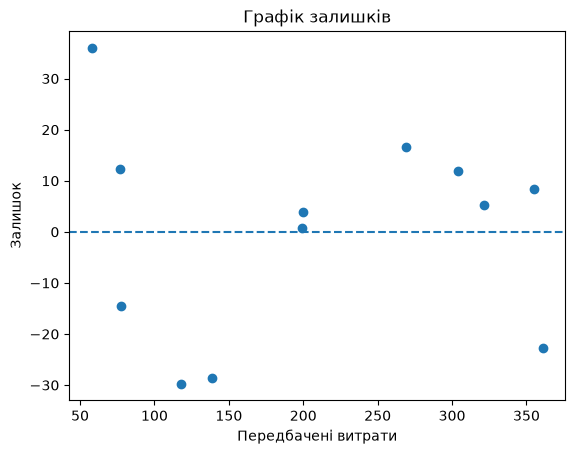

In [15]:
fitted = model.fittedvalues
residuals = model.resid

plt.scatter(
    fitted,
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Передбачені витрати")
plt.ylabel("Залишок")
plt.title("Графік залишків")

plt.show()

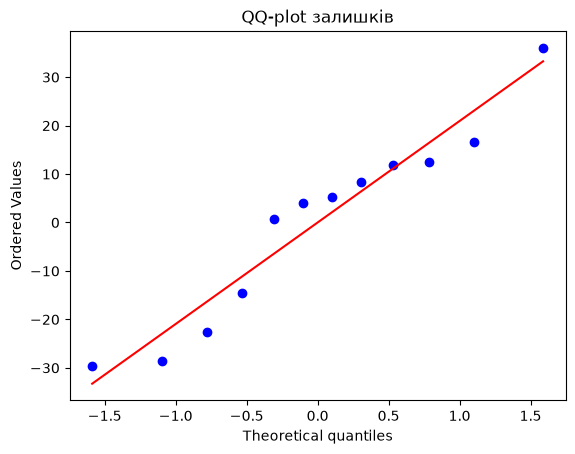

In [16]:
probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("QQ-plot залишків")
plt.show()

### Висновок до Завдання 5

На графіку залишків точки розташовані по обидва боки від нульової лінії. Явної лійкоподібної форми, яка свідчила б про систематичне збільшення або зменшення розкиду залишків із ростом передбачених значень, не спостерігається.

QQ-plot використовується для перевірки відповідності розподілу залишків нормальному розподілу.

За критерієм Шапіро-Вілка отримано `p ≈ 0.435`. Оскільки `p > 0.05`, немає достатніх підстав відхиляти нульову гіпотезу про нормальність залишків.

Отже, за критерієм Шапіро-Вілка нормальність залишків не суперечить отриманим даним при рівні значущості α = 0.05.


In [17]:
from scipy.stats import linregress

simple_result = linregress(
    heating["температура"],
    heating["витрати_на_опалення"]
)

simple_r2 = simple_result.rvalue ** 2

print(f"R² простої регресії: {simple_r2:.3f}")
print(f"Adjusted R² множинної регресії: {model.rsquared_adj:.3f}")

R² простої регресії: 0.968
Adjusted R² множинної регресії: 0.963


### Висновок до Завдання 6

У простій регресії з одним предиктором — температурою — коефіцієнт детермінації становить приблизно **R² = 0.968**.

У множинній моделі з температурою та вологістю adjusted R² становить приблизно **0.963**.

Додавання вологості збільшило звичайний R² приблизно до **0.970**, тобто пояснена частка дисперсії зросла лише незначно.

Adjusted R² при цьому трохи нижчий за R² простої моделі. Це показує, що додавання вологості майже не покращило модель з урахуванням штрафу за додатковий предиктор.

З погляду методу найменших квадратів додавання нового предиктора не може зменшити звичайний R², оскільки модель отримує додаткову можливість пояснювати варіацію залежної змінної. Проте adjusted R² враховує кількість предикторів, тому може не зрости, якщо новий предиктор майже не покращує модель.


## Контрольні питання

### 1. Чому `sm.add_constant()` потрібний перед `sm.OLS()`?

`sm.add_constant()` додає до матриці предикторів стовпець одиниць, який відповідає вільному члену моделі `b0`.

Без цього кроку модель не матиме окремого перетину з віссю Y і фактично буде оцінюватися модель без вільного члена. Це може суттєво змінити коефіцієнти та якість моделі.

### 2. Чим коефіцієнт множинної регресії відрізняється від коефіцієнта простої регресії?

У множинній регресії коефіцієнт показує зміну залежної змінної при зміні конкретного предиктора на одну одиницю **за незмінних інших предикторів**.

У простій регресії є лише один предиктор, тому його коефіцієнт не потребує такого уточнення.

### 3. Чому звичайний R² не може зменшитися при додаванні предиктора?

Додавання нового предиктора розширює набір можливостей моделі для пояснення залежної змінної. Метод найменших квадратів може залишити новий коефіцієнт практично нульовим, якщо предиктор не корисний, але не зобов'язаний погіршувати суму квадратів залишків.

Тому звичайний R² не зменшується навіть після додавання безглуздого предиктора. Через це для порівняння моделей із різною кількістю предикторів корисніше використовувати adjusted R².

### 4. Що означає VIF ≈ 1 і VIF > 10?

VIF приблизно дорівнює 1, коли предиктор практично не пов'язаний з іншими предикторами моделі. Це означає відсутність суттєвої мультиколінеарності.

VIF понад 10 свідчить про серйозну мультиколінеарність. У такій ситуації коефіцієнти можуть бути нестабільними, а їхня індивідуальна інтерпретація — ненадійною. На практиці варто розглянути видалення одного з сильно пов'язаних предикторів, їх об'єднання або інший спосіб побудови моделі.


## Загальний висновок

У практичній роботі для варіанта 7 — Івано-Франківськ — було побудовано множинні лінійні регресійні моделі для прогнозування умовних витрат на опалення.

Для моделі з температурою та вологістю отримано **R² ≈ 0.970** та **adjusted R² ≈ 0.963**. Температура виявилася статистично значущим предиктором, тоді як вологість не була статистично значущою при α = 0.05.

Перевірка VIF показала відсутність проблемної мультиколінеарності між температурою та вологістю: VIF обох предикторів становить приблизно 1.56.

Після додавання кількості опалювальних днів R² зріс до приблизно **0.989**, а adjusted R² — до **0.985**. Водночас VIF температури та опалювальних днів перевищив 10, що свідчить про сильну мультиколінеарність. Це пояснюється тим, що обидві змінні залежать від однієї сезонної хвилі.

Аналіз залишків не виявив очевидної лійкоподібної структури. Критерій Шапіро-Вілка дав `p ≈ 0.435 > 0.05`, тому немає достатніх підстав відхиляти припущення про нормальність залишків.

Отже, додавання предикторів може істотно збільшувати R², але під час вибору моделі необхідно одночасно враховувати adjusted R², статистичну значущість коефіцієнтів та мультиколінеарність.
